# Term Deposit Subscription Prediction

## DevelopersHub Corporation
### Data Science & Analytics Internship


## Problem Statement

Banks often conduct direct marketing campaigns to promote term deposit products. 
However, contacting every customer is costly and inefficient.

The objective of this project is to build a machine learning model that predicts 
whether a customer will subscribe to a term deposit based on demographic, 
financial, and campaign-related information.

## Objectives

- Explore customer data
- Perform preprocessing and feature encoding
- Build classification models
- Compare model performance
- Explain predictions using SHAP
- Generate business insights

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

## Dataset Description

The dataset contains customer attributes and marketing campaign details.

Key Features:

- Age
- Job
- Marital Status
- Education
- Contact Type
- Campaign
- Previous Outcome
- Duration

Target Variable:

y

0 = No Subscription

1 = Subscription

In [4]:
df = pd.read_csv(
    'bank-additional-full.csv',
    sep=';'
)

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.shape

(41188, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Data Cleaning

In [10]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(12)

In [12]:
df.drop_duplicates(inplace=True)

## 9. Exploratory Data Analysis (EDA)

This section should contain many visualizations.

<Axes: xlabel='y', ylabel='count'>

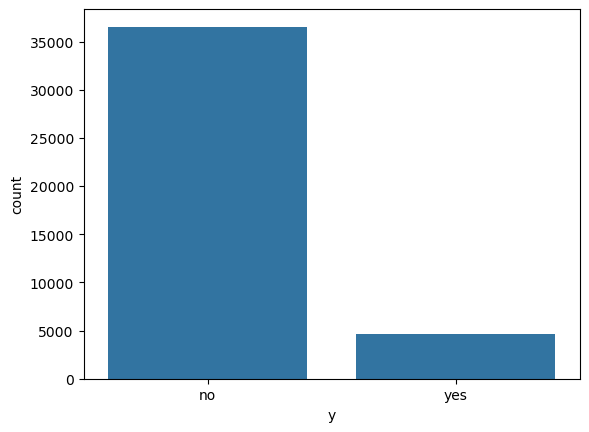

In [13]:
sns.countplot(
    x='y',
    data=df
)

<Axes: xlabel='age', ylabel='Count'>

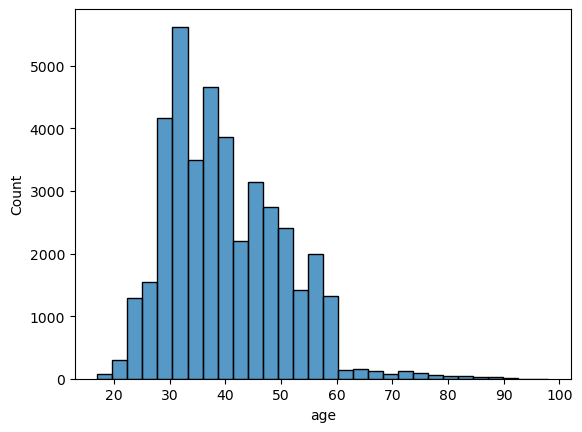

In [14]:
sns.histplot(
    df['age'],
    bins=30
)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'housemaid'),
  Text(1, 0, 'services'),
  Text(2, 0, 'admin.'),
  Text(3, 0, 'blue-collar'),
  Text(4, 0, 'technician'),
  Text(5, 0, 'retired'),
  Text(6, 0, 'management'),
  Text(7, 0, 'unemployed'),
  Text(8, 0, 'self-employed'),
  Text(9, 0, 'unknown'),
  Text(10, 0, 'entrepreneur'),
  Text(11, 0, 'student')])

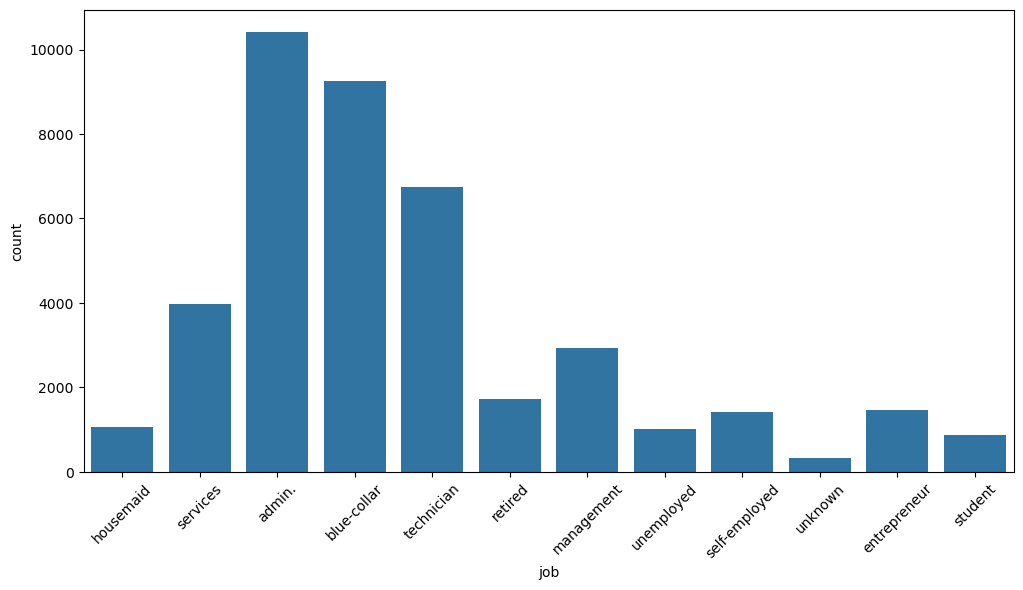

In [15]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='job'
)

plt.xticks(rotation=45)

<Axes: xlabel='education', ylabel='count'>

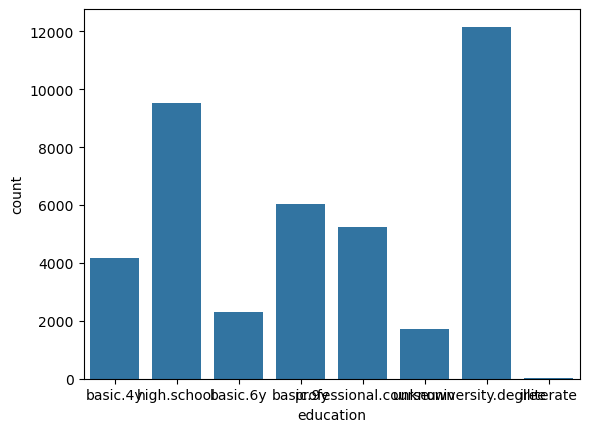

In [16]:
sns.countplot(
    data=df,
    x='education'
)

<Axes: xlabel='marital', ylabel='count'>

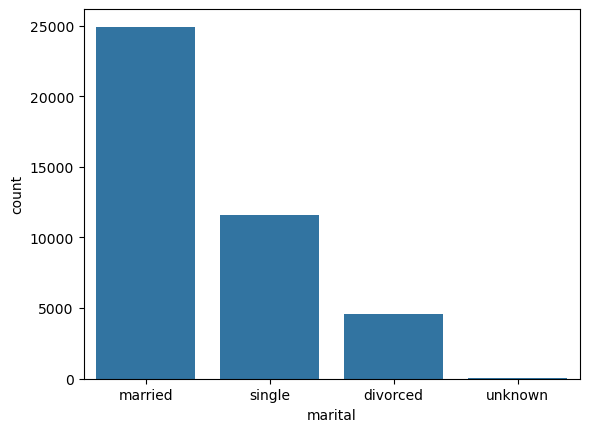

In [17]:
sns.countplot(
    data=df,
    x='marital'
)

<Axes: xlabel='job', ylabel='count'>

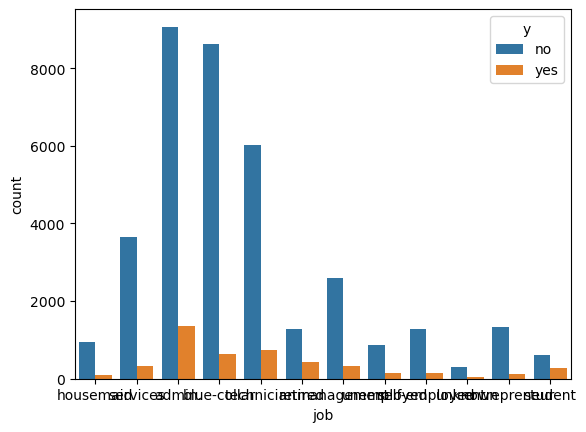

In [18]:
sns.countplot(
    x='job',
    hue='y',
    data=df
)

<Axes: xlabel='education', ylabel='count'>

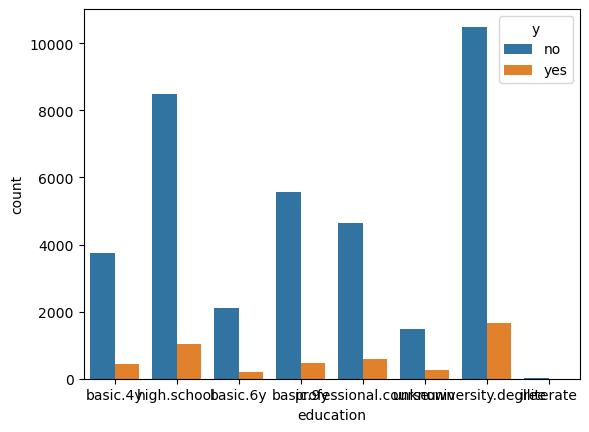

In [19]:
sns.countplot(
    x='education',
    hue='y',
    data=df
)

<Axes: xlabel='contact', ylabel='count'>

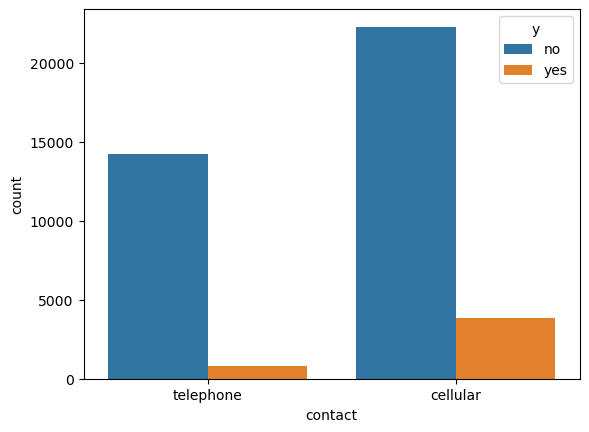

In [20]:
sns.countplot(
    x='contact',
    hue='y',
    data=df
)

<Axes: xlabel='y', ylabel='duration'>

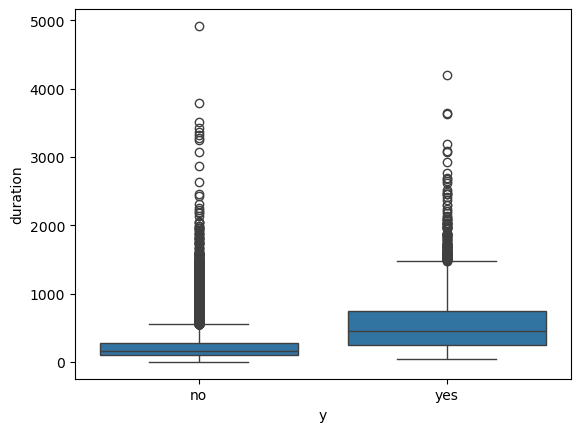

In [21]:
sns.boxplot(
    x='y',
    y='duration',
    data=df
)

In [22]:
df_encoded = df.copy()

In [23]:
encoder = LabelEncoder()

for col in df_encoded.columns:

    if df_encoded[col].dtype == 'object':

        df_encoded[col] = encoder.fit_transform(
            df_encoded[col]
        )

In [24]:
corr = df_encoded.corr()

<Axes: >

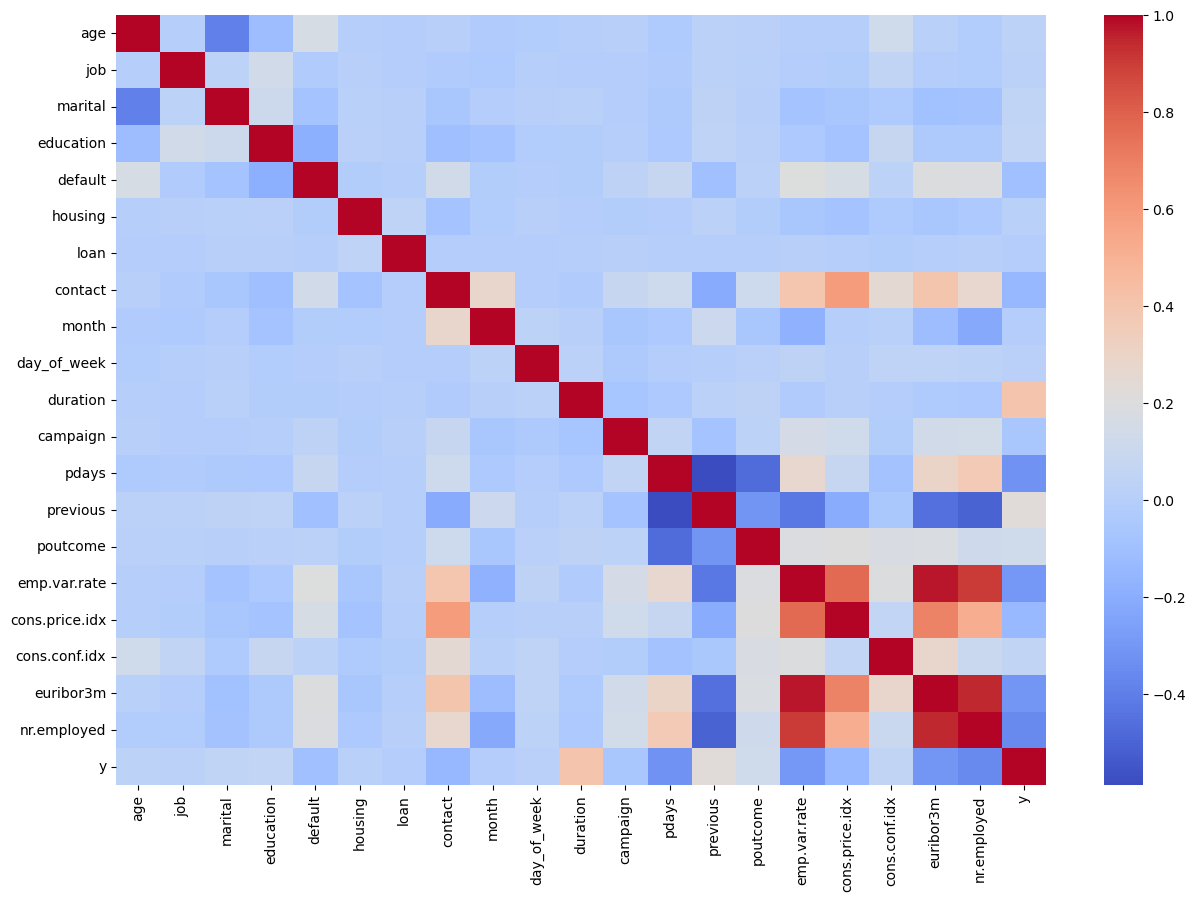

In [25]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

In [26]:
X = df_encoded.drop(
    'y',
    axis=1
)

y = df_encoded['y']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [28]:
lr = LogisticRegression(
    max_iter=3000
)

lr.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=3000)

In [29]:
lr_pred = lr.predict(X_test)

In [30]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.66      0.42      0.51       928

    accuracy                           0.91      8236
   macro avg       0.79      0.69      0.73      8236
weighted avg       0.90      0.91      0.90      8236



In [31]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=300, random_state=42)

In [32]:
rf_pred = rf.predict(X_test)

In [33]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7308
           1       0.65      0.53      0.58       928

    accuracy                           0.91      8236
   macro avg       0.80      0.75      0.77      8236
weighted avg       0.91      0.91      0.91      8236



In [34]:
lr_f1 = f1_score(
    y_test,
    lr_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("LR:", lr_f1)
print("RF:", rf_f1)

LR: 0.5105540897097626
RF: 0.5817965496728138


In [35]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

<Axes: >

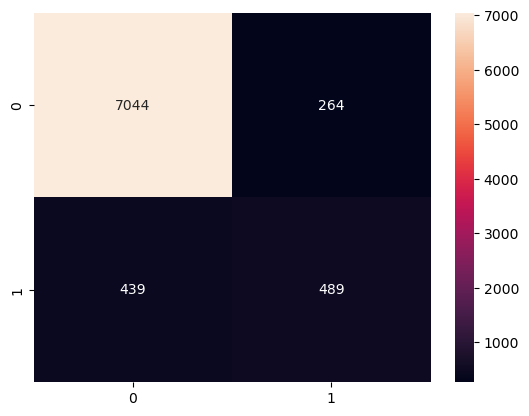

In [36]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

In [37]:
rf_prob = rf.predict_proba(X_test)[:,1]

In [38]:
auc = roc_auc_score(
    y_test,
    rf_prob
)

print(auc)

0.947477551761886


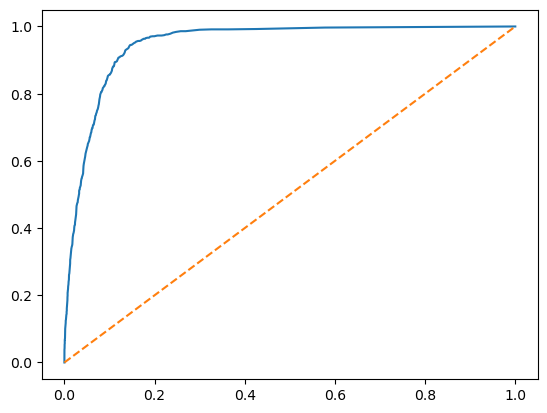

In [39]:
fpr, tpr, threshold = roc_curve(
    y_test,
    rf_prob
)

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

In [40]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

In [41]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

<Axes: xlabel='Importance', ylabel='Feature'>

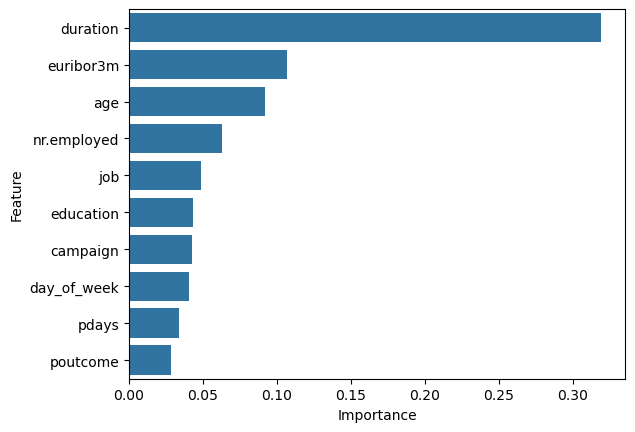

In [42]:
sns.barplot(

    data=importance.head(10),

    y='Feature',

    x='Importance'
)

In [43]:
!pip install shap

In [44]:
import shap

In [ ]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(
    X_test
)

In [ ]:
shap.summary_plot(

    shap_values[1],

    X_test
)

In [ ]:
for i in range(5):

    shap.force_plot(

        explainer.expected_value[1],

        shap_values[1][i],

        X_test.iloc[i],

        matplotlib=True
    )

## Business Insights

1. Customers contacted via cellular channels show higher conversion rates.

2. Call duration strongly influences subscription probability.

3. Previous successful campaigns increase future subscription chances.

4. Targeting high-probability customers can reduce campaign costs.

## Conclusion

Two machine learning models were developed:
- Logistic Regression
- Random Forest

Random Forest achieved superior performance in terms of F1-score and ROC-AUC.

SHAP analysis identified the most influential variables affecting customer subscription decisions.

The model can be used by banks to improve campaign efficiency and customer targeting.